Booting up Sensor Data Analysis...
✅ Data loaded successfully!
We have 7352 individual sensor readings.
Each reading captures 563 different vibration features!

--- Types of Movement Detected ---
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


C:\Users\PARTHIV\AppData\Local\Temp\ipykernel_19784\585850909.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=activity_counts.values, y=activity_counts.index, palette="viridis")


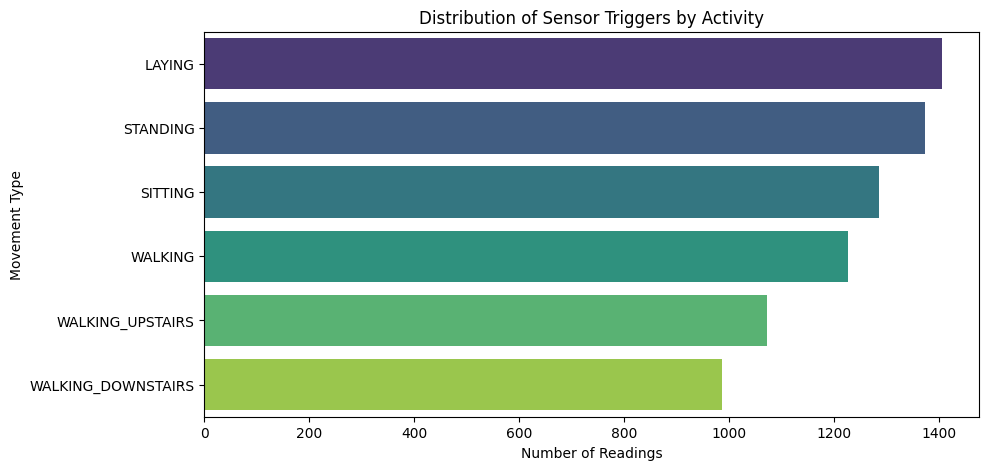

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Booting up Sensor Data Analysis...")

file_path = r"C:\Users\PARTHIV\Documents\Border_Surveillance_Project\Datasets\Human Activity Recognition with Smartphones\train.csv"

# Load the dataset
df = pd.read_csv(file_path)

print(f"✅ Data loaded successfully!")
print(f"We have {df.shape[0]} individual sensor readings.")
print(f"Each reading captures {df.shape[1]} different vibration features!\n")

print("--- Types of Movement Detected ---")
# This counts how many times each action (walking, sitting, etc.) happened
activity_counts = df['Activity'].value_counts()
print(activity_counts)

# Let's visualize the balance of our data
plt.figure(figsize=(10, 5))
sns.barplot(x=activity_counts.values, y=activity_counts.index, palette="viridis")
plt.title("Distribution of Sensor Triggers by Activity")
plt.xlabel("Number of Readings")
plt.ylabel("Movement Type")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Separate features (X) and the target activity (y)
# We drop 'Activity' and 'subject' because 'subject' is just the person's ID number
X = df.drop(['Activity', 'subject'], axis=1)
y = df['Activity']

# 2. Turn the text labels (Walking, Sitting) into numbers (0, 1, 2...) 
# AI models only understand numbers!
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# 3. Split the data: 80% for training the AI, 20% for testing its "honesty"
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Data is ready!")
print(f"Training set: {X_train.shape[0]} sensor samples")
print(f"Testing set: {X_test.shape[0]} sensor samples")
print(f"\nThe AI will now learn to recognize {len(encoder.classes_)} different movement patterns.")

Data is ready!
Training set: 5881 sensor samples
Testing set: 1471 sensor samples

The AI will now learn to recognize 6 different movement patterns.


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Training the Sensor Decision Brain (Random Forest)...")

# 1. Create the model with 100 decision trees
sensor_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model using our training data
sensor_model.fit(X_train, y_train)

print("✅ Training Complete!")

# 3. Test the model's accuracy on the 'unseen' 20% of data
y_pred = sensor_model.predict(X_test)

# 4. Show the results
print("\n--- Model Performance Report ---")
# This tells us how accurate it is for EACH movement (Walking, Sitting, etc.)
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Training the Sensor Decision Brain (Random Forest)...
✅ Training Complete!

--- Model Performance Report ---
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       280
           SITTING       0.95      0.95      0.95       262
          STANDING       0.96      0.95      0.95       276
           WALKING       1.00      0.99      0.99       247
WALKING_DOWNSTAIRS       0.99      0.97      0.98       206
  WALKING_UPSTAIRS       0.97      0.99      0.98       200

          accuracy                           0.98      1471
         macro avg       0.98      0.98      0.98      1471
      weighted avg       0.98      0.98      0.98      1471



In [11]:
import joblib

# 1. Save the trained model
joblib.dump(sensor_model, 'sensor_defense_model.pkl')

# 2. Save the label encoder (so the AI remembers what 0, 1, 2... actually mean)
joblib.dump(encoder, 'sensor_label_encoder.pkl')

print("✅ Sensor Brain successfully saved as 'sensor_defense_model.pkl'!")
print("This model is now ready to be plugged into your final Dashboard.")

✅ Sensor Brain successfully saved as 'sensor_defense_model.pkl'!
This model is now ready to be plugged into your final Dashboard.


In [12]:
# Let's grab a random piece of "New" data from our test set
random_sensor_reading = X_test.iloc[0:1] 

# Ask the AI: "What is this vibration?"
raw_prediction = sensor_model.predict(random_sensor_reading)
decoded_activity = encoder.inverse_transform(raw_prediction)[0]

print("--- LIVE SENSOR ANALYSIS ---")
print(f"Vibration Pattern Detected!")
print(f"AI Decision: This is a person {decoded_activity.upper()}.")

# Check if it was right
actual_activity = encoder.inverse_transform([y_test[0]])[0]
print(f"Ground Truth: {actual_activity.upper()}")

--- LIVE SENSOR ANALYSIS ---
Vibration Pattern Detected!
AI Decision: This is a person WALKING_DOWNSTAIRS.
Ground Truth: WALKING_DOWNSTAIRS
